**Support Vector Machines (SVM)**

The goal of an SVM is to find a decision boundary that stays as far away from the nearest data points of all classes as possible. These nearest points are called Support Vectors.

The Margin: The distance between the decision boundary and the support vectors. SVM maximizes this distance.

Hard vs. Soft Margin: 
* Hard Margin: Strictly separates all points (fails if there is noise/overlap).
* Soft Margin: Allows some misclassifications to achieve a better overall "average" separation (controlled by parameter $C$)

Hinge Loss: The cost function for SVM. It only penalizes points that are on the wrong side of the margin.
$$L = \max(0, 1 - y_i(w \cdot x_i + b))$$


**The Kernel Trick:**
Instead of trying to find a line in the current 2D or 3D space, we project the data into a higher-dimensional space where a linear separation does exist.

* Imagine blue points in a circle and red points surrounding them. You can't draw a line to separate them.
* But if you "lift" the blue points up (into 3D), you can slide a flat sheet of paper (a hyperplane) between them.

**SVM with Gradient Descent** - Hinge Loss
$$\text{Min } \frac{1}{2}||w||^2 + C \left[ \frac{1}{n} \sum \max(0, 1 - y_i(w \cdot x_i + b)) \right]$$


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [11]:
X, y = datasets.make_circles(n_samples=100, factor=0.5, noise=0.05, random_state=42)
y = np.where(y == 0, -1, 1)

In [12]:
def poly_kernel(x1, x2, p=2):
    return (1 + np.dot(x1, x2.T)) ** p

In [17]:
class KernelSVM_GD:
    def __init__(self, kernel=poly_kernel, iterations=500, lr=0.01, lambda_param=0.01):
        self.kernel = kernel
        self.iterations = iterations
        self.lr = lr
        self.lambda_param = lambda_param
        self.alpha = None
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        n_samples = X.shape[0]
        self.alpha = np.zeros(n_samples)

        for _ in range(self.iterations):
            for i in range(n_samples):
                prediction = sum(self.alpha[j] * y[j] * self.kernel(X[i], X[j]) for j in range(n_samples))
                
                if y[i] * prediction < 1:
                    self.alpha[i] += self.lr * (1 - self.lambda_param * self.alpha[i])
                else:
                    self.alpha[i] -= self.lr * self.lambda_param * self.alpha[i]
    
    def predict(self, X):
        y_pred = []
        for x in X:
            prediction = sum(self.alpha[j] * self.y_train[j] * self.kernel(x, self.X_train[j]) for j in range(len(self.alpha)))
            y_pred.append(np.sign(prediction))
        return np.array(y_pred)

In [18]:
model = KernelSVM_GD(iterations=100)
model.fit(X, y)

Linear SVM finds a flat line. For circular data, no flat line exists. By replacing $x^T x$ with a Kernel Function, we mathematically simulate a higher dimension where the circular data becomes a "cone" that can be sliced by a flat plane.

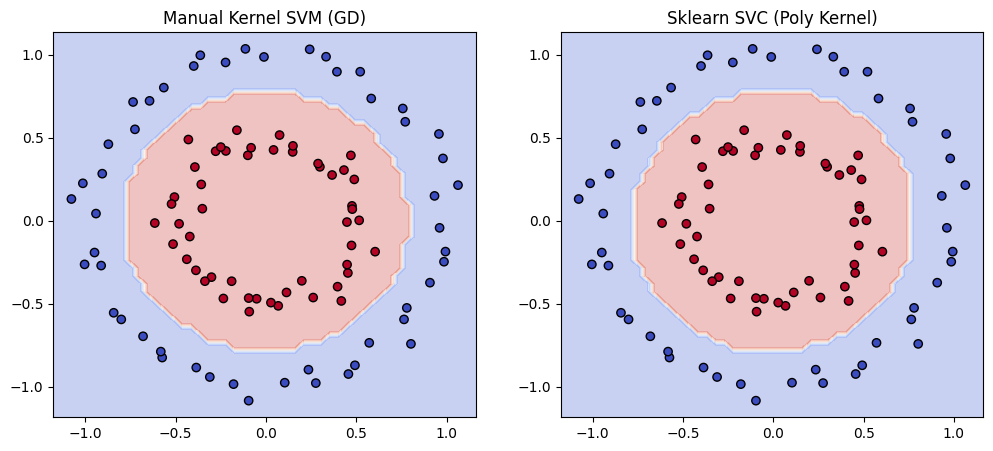

In [19]:

sk_svm = SVC(kernel='poly', degree=2, C=1.0)
sk_svm.fit(X, y)

def plot_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50), np.linspace(y_min, y_max, 50))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    plt.title(title)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_boundary(model, X, y, "Manual Kernel SVM (GD)")
plt.subplot(1, 2, 2)
plot_boundary(sk_svm, X, y, "Sklearn SVC (Poly Kernel)")
plt.show()